
# The AI Confidence Trap
## La IA no es el problema. La dependencia pasiva sí.

Este notebook está diseñado para una entrega de **data storytelling**. La intención no es hacer un modelo complejo, sino construir una historia clara con visualizaciones simples.

**Big Idea**  
En este dataset sintético, el uso intensivo de IA no parece ser el problema por sí solo. La diferencia aparece cuando comparamos a estudiantes que usan IA y siguen construyendo habilidades propias frente a estudiantes que usan IA intensivamente pero muestran bajo aprendizaje autónomo, menor claridad profesional y mayor ansiedad.

**Audiencia:** servicios de carrera, profesores, coordinadores académicos y equipos de éxito estudiantil.  
**Acción esperada:** enseñar a usar IA como herramienta para construir habilidades, no como reemplazo del pensamiento propio.

> Nota importante: el dataset es sintético. El análisis es exploratorio y no establece causalidad.



## 1. Setup y carga de datos

Cargamos el dataset, revisamos su estructura y aplicamos una limpieza mínima para poder graficar sin errores.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

# Use only the real dataset stored in this project folder.
PROJECT_DIR = Path(r"C:\Users\unbue\DataVizProject")
DATA_PATH = PROJECT_DIR / "ai_dependency_career_anxiety_students.csv"
FIG_DIR = PROJECT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

# Load data from the local project folder only.
df = pd.read_csv(DATA_PATH)

# The local CSV has padded column names and a leading "<<" in the first header.
# Normalize those labels so the rest of the notebook can use the intended variable names.
df.columns = [col.strip().lstrip("<").strip() for col in df.columns]

# Normalize text values and recover numeric columns from the padded CSV format.
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip()

# Convert columns that are actually numeric but were read as text because of spacing.
for col in df.columns:
    if col == "student_id":
        continue
    numeric_version = pd.to_numeric(df[col], errors="coerce")
    if numeric_version.notna().mean() >= 0.95:
        df[col] = numeric_version

# Basic cleaning: fill numeric missing values with median and categorical missing values with "Not reported"
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna("Not reported")

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print("Missing values after cleaning:", int(df.isna().sum().sum()))
df.head()

C:\Users\unbue\AppData\Local\Temp\ipykernel_18460\333585737.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


Dataset loaded from: C:\Users\unbue\DataVizProject\ai_dependency_career_anxiety_students.csv
Rows: 15,000
Columns: 30
Missing values after cleaning: 0


C:\Users\unbue\AppData\Local\Temp\ipykernel_18460\333585737.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64



## 2. Variables que usaremos en la historia

No vamos a usar todas las columnas. Para que la historia sea clara, nos enfocamos en tres bloques:

1. **Uso de IA:** `daily_ai_tool_usage_hrs`, `ai_dependency_score`, `ai_replaces_own_thinking_score`.
2. **Respuesta emocional/profesional:** `fear_of_job_loss_to_ai`, `placement_anxiety_score`, `burnout_score`, `motivation_score`.
3. **Construcción de habilidades:** `self_learning_hours_per_week`, `skill_development_courses_taken`, `internship_experience`, `career_clarity_score`, `overall_career_readiness_score`.


In [2]:

story_vars = [
    "daily_ai_tool_usage_hrs", "ai_dependency_score", "ai_replaces_own_thinking_score",
    "fear_of_job_loss_to_ai", "placement_anxiety_score", "burnout_score", "motivation_score",
    "self_learning_hours_per_week", "skill_development_courses_taken", "internship_experience",
    "career_clarity_score", "overall_career_readiness_score", "resume_confidence_score"
]

df[story_vars].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
daily_ai_tool_usage_hrs,15000.0,2.01,1.74,0.0,0.4,1.8,3.20,8.0
ai_dependency_score,15000.0,4.54,2.32,1.0,3.0,4.0,6.00,10.0
ai_replaces_own_thinking_score,15000.0,2.99,1.31,1.0,2.0,3.0,4.00,5.0
fear_of_job_loss_to_ai,15000.0,3.55,1.18,1.0,3.0,4.0,5.00,5.0
placement_anxiety_score,15000.0,5.91,2.55,1.0,4.0,6.0,8.00,10.0
burnout_score,15000.0,5.47,2.07,1.0,4.0,5.0,7.00,10.0
motivation_score,15000.0,4.32,2.15,1.0,3.0,4.0,6.00,10.0
self_learning_hours_per_week,15000.0,6.29,5.51,0.0,1.1,5.5,10.00,31.0
skill_development_courses_taken,15000.0,2.03,1.81,0.0,1.0,2.0,3.00,10.0
internship_experience,15000.0,1.72,1.07,0.0,1.0,2.0,2.00,4.0



## 3. Contexto inicial
### AI is already part of student life

Primero abrimos con un dato simple: el promedio de horas diarias de uso de IA en el dataset.

Este visual funciona como una **slide de contexto**, no como una gráfica técnica.


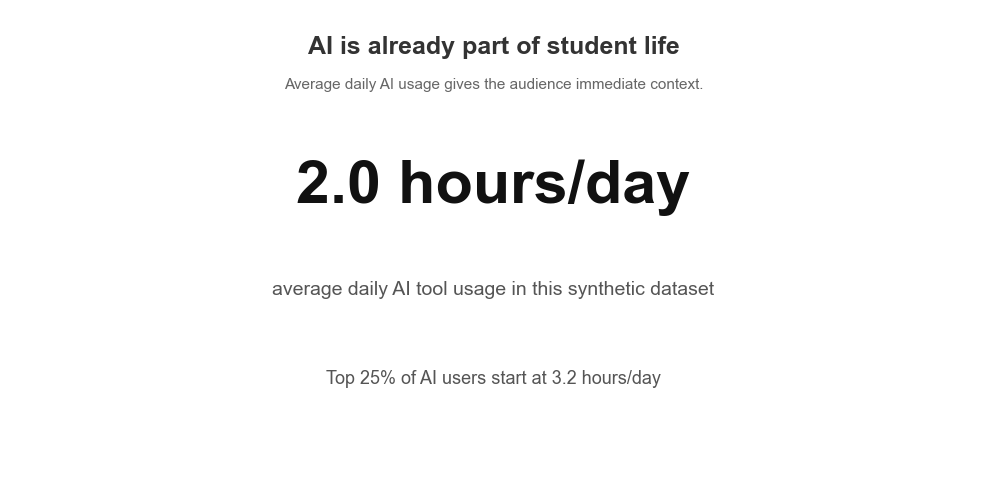

In [3]:
# =========================
# GRAFICA 01 - KPI / TEXTO GRANDE
# Que muestra: promedio de horas diarias de uso de IA.
# =========================

# --- VARIABLES: cambia estas columnas si quieres usar otra metrica.
ai_usage_col = "daily_ai_tool_usage_hrs"

# --- TEXTOS: cambia titulos, subtitulos y frases visibles en la grafica.
chart_title = "AI is already part of student life"
chart_subtitle = "Average daily AI usage gives the audience immediate context."
main_suffix = "hours/day"
subtitle_text = "average daily AI tool usage in this synthetic dataset"
cutoff_text_template = "Top 25% of AI users start at {value:.1f} hours/day"

# --- COLORES Y TIPOGRAFIA: cambia colores, tamanos y peso visual.
title_color = "#333333"
chart_subtitle_color = "#666666"
main_text_color = "#111111"
subtitle_color = "#555555"
main_fontsize = 44
subtitle_fontsize = 14
note_fontsize = 13
title_fontsize = 18
chart_subtitle_fontsize = 11

# --- ESPACIADO: cambia tamano de figura y posicion de cada texto.
fig_size = (10, 5)
title_y = 0.92
chart_subtitle_y = 0.84
main_text_y = 0.62
subtitle_y = 0.40
note_y = 0.21

# --- SALIDA: nombre del archivo generado.
output_filename = "01_kpi_ai_usage.png"

# --- CALCULOS: normalmente no necesitas tocar esto.
avg_ai_hours = df[ai_usage_col].mean()
high_ai_cutoff = df[ai_usage_col].quantile(0.75)
high_ai_share = (df[ai_usage_col] >= high_ai_cutoff).mean() * 100

fig, ax = plt.subplots(figsize=fig_size)
ax.axis("off")
ax.text(0.5, title_y, chart_title, ha="center", va="center",
        fontsize=title_fontsize, fontweight="bold", color=title_color)
ax.text(0.5, chart_subtitle_y, chart_subtitle, ha="center", va="center",
        fontsize=chart_subtitle_fontsize, color=chart_subtitle_color)
ax.text(0.5, main_text_y, f"{avg_ai_hours:.1f} {main_suffix}", ha="center", va="center",
        fontsize=main_fontsize, fontweight="bold", color=main_text_color)
ax.text(0.5, subtitle_y, subtitle_text, ha="center", va="center",
        fontsize=subtitle_fontsize, color=subtitle_color)
ax.text(0.5, note_y, cutoff_text_template.format(value=high_ai_cutoff), ha="center", va="center",
        fontsize=note_fontsize, color=subtitle_color)
plt.tight_layout()
plt.savefig(FIG_DIR / output_filename, dpi=200, bbox_inches="tight")
plt.show()


## 4. El uso de IA cambia según el área académica
### AI use is not evenly distributed across streams

Antes de comparar ansiedad o preparación, conviene mostrar que el uso de IA no es igual en todas las áreas de estudio. Usamos un **lollipop chart** porque se lee como ranking, pero es menos pesado que barras largas.


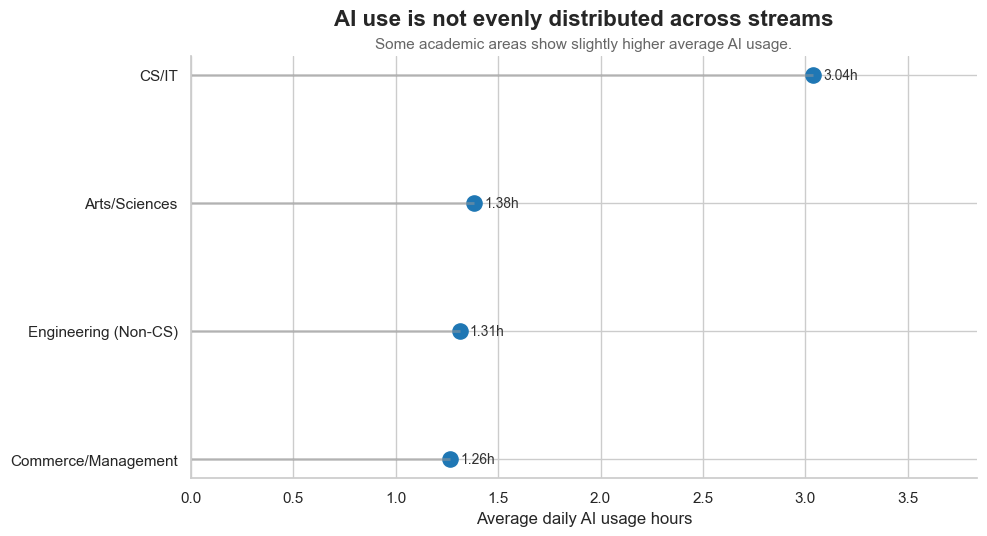

,stream,daily_ai_tool_usage_hrs
2,Commerce/Management,1.26
3,Engineering (Non-CS),1.31
0,Arts/Sciences,1.38
1,CS/IT,3.04


In [4]:
# =========================
# GRAFICA 02 - LOLLIPOP / BARRA CON PUNTO
# Que muestra: promedio de uso de IA por area academica.
# =========================

# --- VARIABLES: cambia estas columnas para comparar otra metrica por otra categoria.
group_col = "stream"
value_col = "daily_ai_tool_usage_hrs"

# --- TEXTOS: cambia titulo, subtitulo y etiqueta del eje X.
chart_title = "AI use is not evenly distributed across streams"
chart_subtitle = "Some academic areas show slightly higher average AI usage."
x_label = "Average daily AI usage hours"
value_suffix = "h"

# --- COLORES: cambia color de linea, punto, etiquetas y subtitulo.
line_color = "#9a9a9a"
point_color = "#1f77b4"
label_color = "#333333"
subtitle_color = "#666666"

# Si quieres colorear una categoria especifica, escribe su nombre exacto aqui.
# Ejemplo: category_color_overrides = {"CS/IT": "#ff3300"}
category_color_overrides = {}

# --- ESTILO: cambia grosor, transparencia, tamano de puntos y etiquetas.
fig_size = (10, 5.5)
line_width = 2
line_alpha = 0.5
point_size = 120
highlight_point_size = 160
value_label_offset = 0.05
value_label_fontsize = 10
title_fontsize = 16
subtitle_fontsize = 11
x_axis_extra_space = 0.8

# --- SALIDA: nombre del archivo generado.
output_filename = "02_lollipop_stream_ai_usage.png"

# --- CALCULOS: normalmente no necesitas tocar esto.
stream_usage = (
    df.groupby(group_col, as_index=False)[value_col]
      .mean()
      .sort_values(value_col)
)

fig, ax = plt.subplots(figsize=fig_size)
y = np.arange(len(stream_usage))

for i, row in stream_usage.reset_index(drop=True).iterrows():
    category = row[group_col]
    value = row[value_col]
    current_color = category_color_overrides.get(category, point_color)
    current_point_size = highlight_point_size if category in category_color_overrides else point_size
    ax.hlines(y=i, xmin=0, xmax=value, linewidth=line_width, alpha=line_alpha, color=line_color)
    ax.scatter(value, i, s=current_point_size, color=current_color)
    ax.text(value + value_label_offset, i, f"{value:.2f}{value_suffix}", va="center",
            fontsize=value_label_fontsize, color=label_color)

ax.set_yticks(y)
ax.set_yticklabels(stream_usage[group_col])
ax.set_xlabel(x_label)
ax.set_title(chart_title, fontsize=title_fontsize, fontweight="bold", pad=22)
ax.text(0.5, 1.01, chart_subtitle, transform=ax.transAxes, ha="center", va="bottom",
        fontsize=subtitle_fontsize, color=subtitle_color)
ax.set_xlim(0, stream_usage[value_col].max() + x_axis_extra_space)
plt.tight_layout()
plt.savefig(FIG_DIR / output_filename, dpi=200, bbox_inches="tight")
plt.show()

stream_usage.round(2)


## 5. Comparación 1: uso intensivo de IA con o sin aprendizaje autónomo
### High AI use looks different when students also learn outside class

Aquí está el primer insight importante: no basta con saber si el estudiante usa mucha IA. Queremos saber si también está construyendo habilidades propias.

Para hacerlo simple, comparamos dos grupos dentro de los estudiantes con **alto uso de IA**:

- **High AI + low self-learning:** estudiantes con alto uso de IA y bajo aprendizaje autónomo.
- **High AI + high self-learning:** estudiantes con alto uso de IA y alto aprendizaje autónomo.

Estos grupos son solo para comparación visual, no son perfiles definitivos ni diagnósticos.


In [5]:

# Cutoffs used only to create clear comparison groups
high_ai_cutoff = df["daily_ai_tool_usage_hrs"].quantile(0.75)
low_self_cutoff = df["self_learning_hours_per_week"].quantile(0.25)
high_self_cutoff = df["self_learning_hours_per_week"].quantile(0.75)

high_ai = df[df["daily_ai_tool_usage_hrs"] >= high_ai_cutoff].copy()

ai_low_self = high_ai[high_ai["self_learning_hours_per_week"] <= low_self_cutoff]
ai_high_self = high_ai[high_ai["self_learning_hours_per_week"] >= high_self_cutoff]

print(f"High AI use cutoff: {high_ai_cutoff:.2f} hours/day")
print(f"Low self-learning cutoff: <= {low_self_cutoff:.2f} hours/week")
print(f"High self-learning cutoff: >= {high_self_cutoff:.2f} hours/week")
print(f"High AI + low self-learning students: {len(ai_low_self):,}")
print(f"High AI + high self-learning students: {len(ai_high_self):,}")


High AI use cutoff: 3.20 hours/day
Low self-learning cutoff: <= 1.10 hours/week
High self-learning cutoff: >= 10.00 hours/week
High AI + low self-learning students: 321
High AI + high self-learning students: 1,785


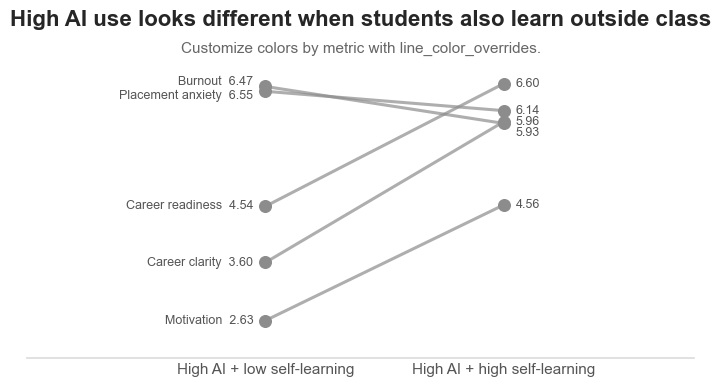

,metric,High AI + low self-learning,High AI + high self-learning,difference
0,Career readiness,4.54,6.60,2.05
1,Career clarity,3.60,5.96,2.36
2,Motivation,2.63,4.56,1.93
3,Placement anxiety,6.55,5.93,-0.62
4,Burnout,6.47,6.14,-0.32


In [254]:
# =========================
# FUNCIONES PARA COMPARACIONES Y SLOPE GRAPHS
# Si quieres cambiar el diseno general de TODOS los slope graphs, cambia la funcion slope_graph().
# Si solo quieres cambiar una grafica especifica, modifica el bloque CONFIGURA AQUI de esa grafica.
# =========================

def create_comparison_df(group_a, group_b, label_a, label_b, metrics, metric_labels):
    """Crea una tabla con el promedio de cada metrica para dos grupos."""
    rows = []
    for metric in metrics:
        rows.append({
            "metric": metric_labels.get(metric, metric),
            label_a: group_a[metric].mean(),
            label_b: group_b[metric].mean(),
            "difference": group_b[metric].mean() - group_a[metric].mean()
        })
    return pd.DataFrame(rows)


def slope_graph(
    comp_df,
    label_left,
    label_right,
    title,
    filename,
    subtitle="",
    left_color="#8c8c8c",
    right_color="#8c8c8c",
    down_color="#8c8c8c",
    line_color_overrides=None,
    label_y_offsets=None,
    right_value_y_offsets=None,
    subtitle_color="#666666",
    label_color="#555555",
    figsize=(7, 4),
    y_limits=(0, 10),
    x_limits=(-0.55, 1.35),
    line_width=2.2,
    line_alpha=0.70,
    point_size=70,
    emphasis_line_width=4.0,
    emphasis_point_size=115,
    left_label_offset=-0.05,
    right_label_offset=0.05,
    label_fontsize=9,
    title_fontsize=16,
    subtitle_fontsize=11,
    axis_label_fontsize=11,
    grid_alpha=0,
    title_pad=24,
    y_axis_label="",
    save_dpi=200
    
):
    """Dibuja un line slope graph limpio y editable.

    Elementos editables importantes:
    - line_color_overrides: cambia el color de una linea especifica.
      Ejemplo: {"Career readiness": "#ff3300"}
    - label_y_offsets: mueve SOLO las etiquetas de texto, no los puntos ni los datos.
      Ejemplo: {"Burnout": -0.12, "Motivation": 0.10}
      Valores positivos suben la etiqueta; valores negativos la bajan.
    - y_axis_label="": deja el eje Y sin label para un estilo mas editorial.
    """
    if line_color_overrides is None:
        line_color_overrides = {}

    if right_value_y_offsets is None:
        right_value_y_offsets = {}
    
    if label_y_offsets is None:
        label_y_offsets = {}

    plot_df = comp_df.copy()
    fig, ax = plt.subplots(figsize=figsize)
    x_left, x_right = 0, 1

    for _, row in plot_df.iterrows():
        metric_name = row["metric"]

        # Color base: gris si sube o baja. El color de enfasis se define en line_color_overrides.
        base_color = right_color if row[label_right] >= row[label_left] else down_color
        color = line_color_overrides.get(metric_name, base_color)
        is_emphasized = metric_name in line_color_overrides

        current_line_width = emphasis_line_width if is_emphasized else line_width
        current_point_size = emphasis_point_size if is_emphasized else point_size
        current_alpha = 1.0 if is_emphasized else line_alpha
        current_zorder = 5 if is_emphasized else 3

        # IMPORTANTE: puntos y linea usan los valores reales. No se alteran con label_y_offsets.
        ax.plot(
            [x_left, x_right],
            [row[label_left], row[label_right]],
            color=color,
            linewidth=current_line_width,
            alpha=current_alpha,
            solid_capstyle="round",
            zorder=current_zorder
        )
        ax.scatter(
            [x_left, x_right],
            [row[label_left], row[label_right]],
            color=color,
            s=current_point_size,
            zorder=current_zorder + 1
        )

        # Este offset mueve SOLO las etiquetas para evitar encimes.

        # Estos offsets mueven SOLO textos, no puntos ni datos.
        left_text_y_offset = label_y_offsets.get(metric_name, 0)
        right_text_y_offset = right_value_y_offsets.get(metric_name, 0)

        left_text_y = row[label_left] + left_text_y_offset
        right_text_y = row[label_right] + right_text_y_offset

        ax.text(
            x_left + left_label_offset,
            left_text_y,
            f"{metric_name}  {row[label_left]:.2f}",
            ha="right",
            va="center",
            fontsize=label_fontsize,
            color=color if is_emphasized else label_color,
            fontweight="bold" if is_emphasized else "normal"
        )
        ax.text(
            x_right + right_label_offset,
            right_text_y,
            f"{row[label_right]:.2f}",
            ha="left",
            va="center",
            fontsize=label_fontsize,
            color=color if is_emphasized else label_color,
            fontweight="bold" if is_emphasized else "normal"
        )

    ax.set_xlim(*x_limits)
    ax.set_ylim(*y_limits)
    ax.set_xticks([x_left, x_right])
    ax.set_xticklabels([label_left, label_right], fontsize=axis_label_fontsize)

    # Si y_axis_label="", no se muestra label del eje Y.
    if y_axis_label:
        ax.set_ylabel(y_axis_label, fontsize=axis_label_fontsize)
    else:
        ax.set_ylabel("")

    ax.set_title(title, fontsize=title_fontsize, fontweight="bold", pad=title_pad)
    if subtitle:
        ax.text(
            0.5,
            1.01,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=subtitle_fontsize,
            color=subtitle_color
        )

    # Estilo editorial: poco grid, sin bordes innecesarios, etiquetas directas.
    ax.grid(axis="y", alpha=grid_alpha, linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="y", length=0, labelleft=False)
    ax.tick_params(axis="x", length=0, colors="#555555")
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#dddddd")

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=save_dpi, bbox_inches="tight")
    plt.show()

# --- ETIQUETAS DE METRICAS: cambia el texto visible de cada variable en los slope graphs.
metric_labels = {
    "overall_career_readiness_score": "Career readiness",
    "career_clarity_score": "Career clarity",
    "motivation_score": "Motivation",
    "placement_anxiety_score": "Placement anxiety",
    "burnout_score": "Burnout"
}

# --- VARIABLES BASE: cambia esta lista si quieres que los slope graphs usen otras metricas.
core_metrics = list(metric_labels.keys())

# =========================
# GRAFICA 03 - SLOPE GRAPH
# Que muestra: alto uso de IA con bajo vs alto aprendizaje autonomo.
# =========================

# --- VARIABLES / GRUPOS: cambia grupos o metricas a comparar.
left_group = ai_low_self
right_group = ai_high_self
left_label = "High AI + low self-learning"
right_label = "High AI + high self-learning"
metrics_to_plot = core_metrics

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "High AI use looks different when students also learn outside class"
chart_subtitle = "Customize colors by metric with line_color_overrides."
output_filename = "03_slope_high_ai_self_learning.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: cambia aqui la linea que quieras destacar.
# Los nombres deben coincidir con metric_labels: Career readiness, Career clarity, Motivation, Placement anxiety, Burnout.
line_color_overrides = {
    # "Career clarity": "#0004ff",
    # "Burnout": "#9467bd",
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    # "Career readiness": 0.10,
     "Burnout": 0.15,
     "Placement anxiety": -.15
}


right_value_y_offsets = {
    "Career clarity": 0,
    "Placement anxiety": -0.16,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (7, 4)
y_limits = (2, 7)
x_limits = (-1.00, 1.8)


comp_self_learning = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_self_learning,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits,
    right_value_y_offsets=right_value_y_offsets
)

comp_self_learning.round(2)


**Insight:** Entre los estudiantes con alto uso de IA, los que también tienen alto aprendizaje autónomo muestran mayor preparación, claridad y motivación. Esto cambia la historia: el uso intensivo de IA no se interpreta igual cuando existe construcción activa de habilidades.



## 6. Comparación 2: miedo al reemplazo laboral con acción o sin acción
### Fear can become action — or just anxiety

Esta comparación parte de estudiantes con alto miedo a perder oportunidades laborales por la IA. Luego preguntamos:

> ¿Ese miedo viene acompañado de acciones concretas para desarrollar habilidades?

Comparamos:

- **Fear + no action:** alto miedo, bajo aprendizaje autónomo y pocos cursos.
- **Fear + action:** alto miedo, alto aprendizaje autónomo y más cursos de desarrollo de habilidades.


In [255]:

high_fear_cutoff = df["fear_of_job_loss_to_ai"].quantile(0.75)
low_courses_cutoff = df["skill_development_courses_taken"].quantile(0.25)
high_courses_cutoff = df["skill_development_courses_taken"].quantile(0.75)

high_fear = df[df["fear_of_job_loss_to_ai"] >= high_fear_cutoff].copy()

fear_no_action = high_fear[
    (high_fear["self_learning_hours_per_week"] <= low_self_cutoff) &
    (high_fear["skill_development_courses_taken"] <= low_courses_cutoff)
]

fear_action = high_fear[
    (high_fear["self_learning_hours_per_week"] >= high_self_cutoff) &
    (high_fear["skill_development_courses_taken"] >= high_courses_cutoff)
]

print(f"High fear cutoff: >= {high_fear_cutoff:.0f} on a 1–5 scale")
print(f"Fear + no action students: {len(fear_no_action):,}")
print(f"Fear + action students: {len(fear_action):,}")


High fear cutoff: >= 5 on a 1–5 scale
Fear + no action students: 582
Fear + action students: 566


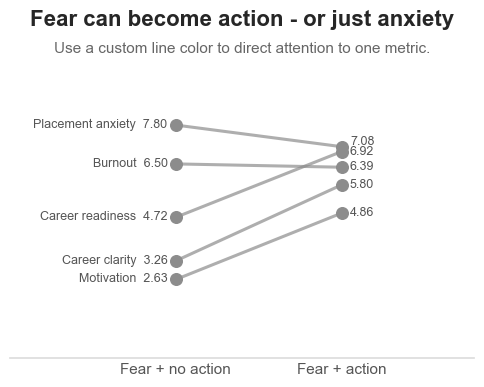

,metric,Fear + no action,Fear + action,difference
0,Career readiness,4.72,6.92,2.20
1,Career clarity,3.26,5.80,2.54
2,Motivation,2.63,4.86,2.22
3,Placement anxiety,7.80,7.08,-0.72
4,Burnout,6.50,6.39,-0.11


In [267]:
# =========================
# GRAFICA 04 - SLOPE GRAPH
# Que muestra: estudiantes con miedo a reemplazo de IA sin accion vs con accion.
# =========================

# --- VARIABLES / GRUPOS: cambia estos grupos si quieres otra comparacion.
left_group = fear_no_action
right_group = fear_action
left_label = "Fear + no action"
right_label = "Fear + action"
metrics_to_plot = core_metrics

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "Fear can become action - or just anxiety"
chart_subtitle = "Use a custom line color to direct attention to one metric."
output_filename = "04_slope_fear_action.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: descomenta o agrega metricas para cambiar colores.
line_color_overrides = {
    # "Career readiness": "#2ca02c",
    # "Placement anxiety": "#d62728",
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    # "Career readiness": 0.10,
    # "Burnout": -0.12,
}

right_value_y_offsets = {
    "Placement anxiety": 0.17,
    # "Burnout": -0.10,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (5, 4)
y_limits = (0,10)
x_limits = (-1.00, 1.8)

comp_fear_action = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_fear_action,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits,
    right_value_y_offsets=right_value_y_offsets
)

comp_fear_action.round(2)


**Insight:** El miedo al reemplazo laboral no necesariamente lleva a una misma respuesta. En este dataset, quienes responden con aprendizaje autónomo y cursos muestran más readiness, claridad y motivación que quienes tienen miedo pero no invierten en habilidades.



## 7. Comparación 3: alta dependencia de IA con o sin cursos de habilidades
### Skill-building changes the meaning of dependency

Ahora filtramos estudiantes con alta dependencia de IA y revisamos si los cursos de habilidades cambian la lectura.

Comparamos:

- **High dependency + few courses**
- **High dependency + more courses**


In [257]:

high_dependency_cutoff = df["ai_dependency_score"].quantile(0.75)
high_dep = df[df["ai_dependency_score"] >= high_dependency_cutoff].copy()

dep_few_courses = high_dep[high_dep["skill_development_courses_taken"] <= low_courses_cutoff]
dep_more_courses = high_dep[high_dep["skill_development_courses_taken"] >= high_courses_cutoff]

print(f"High AI dependency cutoff: >= {high_dependency_cutoff:.1f} on a 1–10 scale")
print(f"High dependency + few courses students: {len(dep_few_courses):,}")
print(f"High dependency + more courses students: {len(dep_more_courses):,}")


High AI dependency cutoff: >= 6.0 on a 1–10 scale
High dependency + few courses students: 2,449
High dependency + more courses students: 1,519


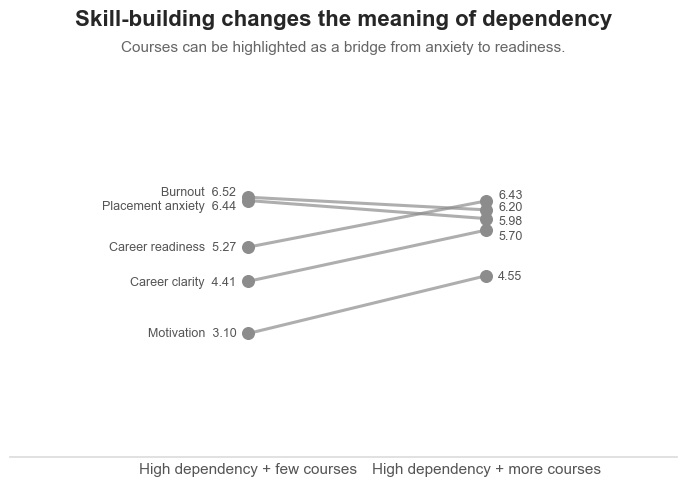

,metric,High dependency + few courses,High dependency + more courses,difference
0,Career readiness,5.27,6.43,1.16
1,Career clarity,4.41,5.70,1.29
2,Motivation,3.10,4.55,1.45
3,Placement anxiety,6.44,5.98,-0.45
4,Burnout,6.52,6.20,-0.32


In [279]:
# =========================
# GRAFICA 05 - SLOPE GRAPH
# Que muestra: alta dependencia con pocos vs mas cursos de habilidades.
# =========================

# --- VARIABLES: cambia la lista si quieres mostrar menos/mas metricas en esta grafica.
metrics_courses = [
    "overall_career_readiness_score",
    "career_clarity_score",
    "motivation_score",
    "placement_anxiety_score",
    "burnout_score"
]

# --- GRUPOS.
left_group = dep_few_courses
right_group = dep_more_courses
left_label = "High dependency + few courses"
right_label = "High dependency + more courses"
metrics_to_plot = metrics_courses

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "Skill-building changes the meaning of dependency"
chart_subtitle = "Courses can be highlighted as a bridge from anxiety to readiness."
output_filename = "05_slope_dependency_courses.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: descomenta o agrega metricas para cambiar colores.
line_color_overrides = {
    # "Career clarity": "#ff7f0e",
    # "Burnout": "#d62728",
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    # "Career readiness": 0.10,
    "Burnout": .12,
    "Placement anxiety": -.12
}

right_value_y_offsets = {
    "Burnout": 0.06,
    "Placement anxiety": -0.06,
    "Career readiness": .15,
    "Career clarity": -0.15,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (7, 5)
y_limits = (0, 10)
x_limits = (-1.00, 1.8)

comp_courses = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_courses,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits,
    right_value_y_offsets=right_value_y_offsets,
)

comp_courses.round(2)


**Insight:** La dependencia de IA no debe leerse de forma aislada. Cuando los estudiantes con alta dependencia también toman más cursos, aparecen mejores señales de claridad, motivación y preparación profesional.



## 8. Comparación 4: uso intensivo de IA con o sin internship
### Practice still builds career readiness

Esta comparación conecta directamente con la idea de preparación profesional. Dentro de estudiantes con alto uso de IA, comparamos a quienes tienen experiencia de internship contra quienes no la tienen.


In [259]:

high_ai_no_internship = high_ai[high_ai["internship_experience"] == 0]
high_ai_with_internship = high_ai[high_ai["internship_experience"] >= 1]

print(f"High AI + no internship students: {len(high_ai_no_internship):,}")
print(f"High AI + internship students: {len(high_ai_with_internship):,}")


High AI + no internship students: 525
High AI + internship students: 3,319


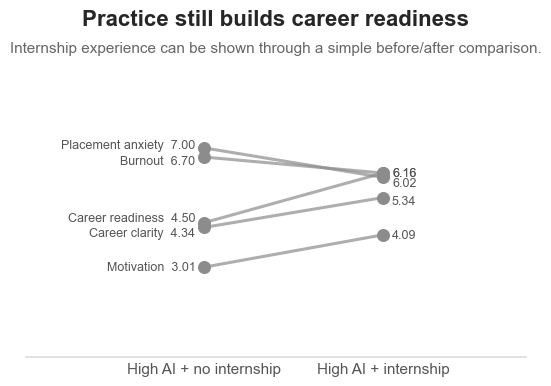

,metric,High AI + no internship,High AI + internship,difference
0,Career readiness,4.50,6.16,1.66
1,Career clarity,4.34,5.34,1.00
2,Motivation,3.01,4.09,1.08
3,Placement anxiety,7.00,6.02,-0.99
4,Burnout,6.70,6.16,-0.54


In [302]:
# =========================
# GRAFICA 06 - SLOPE GRAPH
# Que muestra: alto uso de IA sin internship vs con internship.
# =========================

# --- VARIABLES / GRUPOS.
left_group = high_ai_no_internship
right_group = high_ai_with_internship
left_label = "High AI + no internship"
right_label = "High AI + internship"
metrics_to_plot = core_metrics

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "Practice still builds career readiness"
chart_subtitle = "Internship experience can be shown through a simple before/after comparison."
output_filename = "06_slope_high_ai_internship.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: descomenta o agrega metricas para cambiar colores.
line_color_overrides = {
    # "Career readiness": "#9467bd",
    # "Motivation": "#2ca02c",
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    "Placement anxiety": 0.12,
    "Burnout": -0.12,
    "Career readiness": .15,
    "Career clarity": -.17
}

right_value_y_offsets = {
    "Career clarity": -.1,
    "Placement anxiety": -0.2,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (6, 4)
y_limits = (0, 10)
x_limits = (-1.00, 1.8)

comp_internship = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_internship,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits,
    right_value_y_offsets=right_value_y_offsets
)

comp_internship.round(2)


**Insight:** Incluso entre estudiantes que usan IA intensivamente, la experiencia práctica cambia la lectura. La IA puede ayudar, pero la experiencia real sigue siendo una fuente importante de confianza y preparación.



## 9. Comparación 5: cuando la IA reemplaza el pensamiento propio
### The warning sign is replacement, not usage

Para cerrar la evidencia central, comparamos estudiantes con bajo y alto puntaje en `ai_replaces_own_thinking_score`.

Esta comparación va al corazón de la historia: **usar IA no es el problema; el problema aparece cuando el estudiante siente que la IA reemplaza su propio razonamiento.**


In [261]:

low_replacement_cutoff = df["ai_replaces_own_thinking_score"].quantile(0.25)
high_replacement_cutoff = df["ai_replaces_own_thinking_score"].quantile(0.75)

low_replacement = df[df["ai_replaces_own_thinking_score"] <= low_replacement_cutoff]
high_replacement = df[df["ai_replaces_own_thinking_score"] >= high_replacement_cutoff]

print(f"Low replacement cutoff: <= {low_replacement_cutoff:.0f} on a 1–5 scale")
print(f"High replacement cutoff: >= {high_replacement_cutoff:.0f} on a 1–5 scale")
print(f"Low replacement students: {len(low_replacement):,}")
print(f"High replacement students: {len(high_replacement):,}")


Low replacement cutoff: <= 2 on a 1–5 scale
High replacement cutoff: >= 4 on a 1–5 scale
Low replacement students: 5,634
High replacement students: 5,451


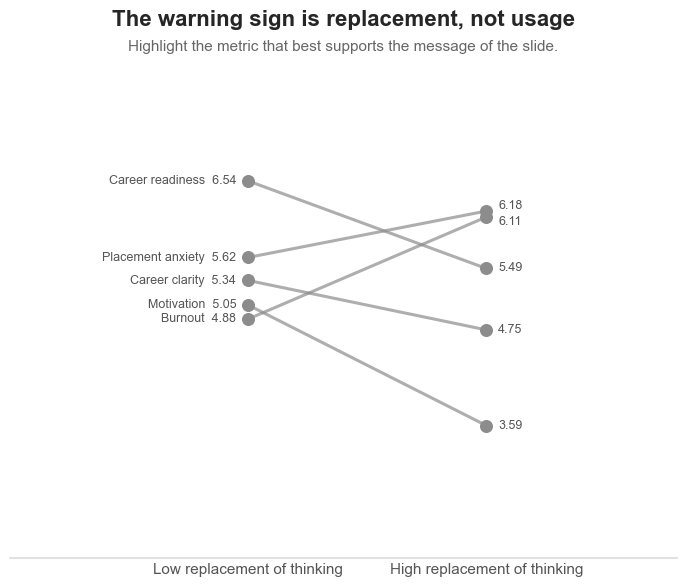

,metric,Low replacement of thinking,High replacement of thinking,difference
0,Career readiness,6.54,5.49,-1.05
1,Career clarity,5.34,4.75,-0.60
2,Motivation,5.05,3.59,-1.45
3,Placement anxiety,5.62,6.18,0.56
4,Burnout,4.88,6.11,1.23


In [324]:
# =========================
# GRAFICA 07 - SLOPE GRAPH
# Que muestra: bajo vs alto reemplazo del pensamiento propio.
# =========================

# --- VARIABLES / GRUPOS.
left_group = low_replacement
right_group = high_replacement
left_label = "Low replacement of thinking"
right_label = "High replacement of thinking"
metrics_to_plot = core_metrics

# --- TEXTOS Y SALIDA: cambia titulo, subtitulo y archivo PNG generado.
chart_title = "The warning sign is replacement, not usage"
chart_subtitle = "Highlight the metric that best supports the message of the slide."
output_filename = "07_slope_replacement_thinking.png"

# --- COLORES GENERALES: gris base para lineas; usa line_color_overrides para enfasis.
left_color = "#8c8c8c"
right_color = "#8c8c8c"
down_color = "#8c8c8c"
subtitle_color = "#666666"

# --- COLOR POR LINEA: descomenta o agrega metricas para cambiar colores.
line_color_overrides = {
    # "Placement anxiety": "#d62728",
    # "Career readiness": "#1f77b4",
}

# --- OFFSETS DE ETIQUETAS: mueve SOLO textos si se enciman. Positivo sube, negativo baja.
label_y_offsets = {
    # "Career readiness": 0.10,
    # "Burnout": -0.12,
}
right_value_y_offsets = {
    "Placement anxiety": 0.06,
    "Burnout": -0.06,
}

# --- LABEL DEL EJE Y: deja "" para quitarlo y tener estilo mas limpio.
y_axis_label = ""

# --- ESPACIADO / TAMANO: modifica tamano, baseline del eje Y y espacio horizontal.
fig_size = (7, 6)
y_limits = (2, 8)
x_limits = (-1.00, 1.8)

comp_replacement = create_comparison_df(
    left_group,
    right_group,
    left_label,
    right_label,
    metrics_to_plot,
    metric_labels
)

slope_graph(
    comp_replacement,
    left_label,
    right_label,
    chart_title,
    output_filename,
    subtitle=chart_subtitle,
    left_color=left_color,
    right_color=right_color,
    down_color=down_color,
    line_color_overrides=line_color_overrides,
    subtitle_color=subtitle_color,
    label_y_offsets=label_y_offsets,
    y_axis_label=y_axis_label,
    figsize=fig_size,
    y_limits=y_limits,
    x_limits=x_limits,
    right_value_y_offsets=right_value_y_offsets
)

comp_replacement.round(2)


**Insight:** Cuando la IA reemplaza más el pensamiento propio, los estudiantes muestran menor readiness, menor claridad y menor motivación, mientras que ansiedad y burnout suben. Este es el argumento central de la historia.



## 10. Resumen de insights

1. **El uso de IA no debe interpretarse solo por horas.** El mismo nivel alto de uso puede verse distinto si el estudiante también desarrolla habilidades propias.
2. **El aprendizaje autónomo cambia la lectura del alto uso de IA.** Quienes usan mucha IA y también aprenden por fuera muestran mejores señales de preparación.
3. **El miedo al reemplazo puede transformarse en acción o en ansiedad.** La diferencia aparece cuando hay cursos, self-learning y desarrollo de habilidades.
4. **La experiencia práctica sigue siendo clave.** Entre estudiantes con alto uso de IA, quienes tienen internship muestran más readiness y claridad.
5. **La señal crítica es el reemplazo del pensamiento propio.** Cuando la IA sustituye el razonamiento del estudiante, aparecen peores indicadores de motivación, claridad y preparación.

**Conclusión:** La universidad no debería enfocarse en prohibir el uso de IA, sino en enseñar a usarla como herramienta de construcción de habilidades.


## 11. Storyboard para presentacion

| Slide | Titulo accionable | Visual | Mensaje |
|---|---|---|---|
| 1 | **AI is already part of student life** | KPI / texto grande | La IA ya esta presente en la rutina estudiantil. |
| 2 | **AI use is not evenly distributed across streams** | Lollipop chart | El uso de IA cambia por area academica. |
| 3 | **High AI use looks different when students also learn outside class** | Slope graph | Alto uso de IA no significa lo mismo si existe aprendizaje autonomo. |
| 4 | **Fear can become action - or just anxiety** | Slope graph | El miedo al reemplazo puede ir acompanado de accion o de ansiedad. |
| 5 | **Skill-building changes the meaning of dependency** | Slope graph | Los cursos de habilidades modifican como se interpreta la dependencia. |
| 6 | **Practice still builds career readiness** | Slope graph | La experiencia practica sigue siendo clave para readiness. |
| 7 | **The warning sign is replacement, not usage** | Slope graph | El verdadero riesgo aparece cuando la IA reemplaza el pensamiento propio. |
| 8 | **Universities should teach AI as a skill-building tool** | Slide de recomendacion | La solucion es guiar el uso de IA, no prohibirlo. |


## 12. Recomendaciones para la audiencia

- Crear talleres de **AI literacy** donde los estudiantes aprendan a usar IA como apoyo al razonamiento.
- Integrar IA con programas de **career readiness**, no tratarla como una herramienta separada.
- Promover aprendizaje autónomo, cursos de habilidades, internships y práctica de entrevistas.
- Detectar estudiantes que usan IA intensivamente pero no están desarrollando habilidades propias.
- Evitar comunicar la IA como amenaza absoluta: el problema no es usarla, sino depender de ella sin construir capacidades.



## 13. Limitaciones

- El dataset es sintético; por lo tanto, los resultados no deben interpretarse como evidencia real sobre estudiantes.
- El análisis es exploratorio y descriptivo.
- No se hacen afirmaciones causales.
- Los grupos comparados se crean solo para contar una historia visual y no representan diagnósticos.
- Para tomar decisiones institucionales reales se necesitarían datos reales de estudiantes, encuestas validadas y revisión ética.



## 14. Reflexión

El principal reto fue evitar una historia demasiado simple como “más IA = más ansiedad”. Esa lectura era fácil, pero limitada. La versión final busca una historia más útil: el uso de IA puede ser positivo si se combina con aprendizaje autónomo, cursos, internships y claridad profesional. El diseño de las visualizaciones busca comparar comportamientos, no solo mostrar líneas que suben. Esto hace que el storytelling sea más humano, más accionable y más alineado con una audiencia universitaria.


In [263]:
# Save cleaned sample for submission in the project folder.
sample_path = Path(r"C:\Users\unbue\DataVizProject\ai_confidence_trap_comparison_clean_sample.csv")
df.sample(min(5000, len(df)), random_state=42).to_csv(sample_path, index=False)
print(f"Clean sample saved to: {sample_path}")
print(f"Figures saved to: {FIG_DIR}")

Clean sample saved to: C:\Users\unbue\DataVizProject\ai_confidence_trap_comparison_clean_sample.csv
Figures saved to: C:\Users\unbue\DataVizProject\figures
